# Create SWOT image with different filter/ differentiation

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import dask.array as da

import matplotlib.pyplot as plt

import os
from glob import glob
from swot import browse_swot_250m, browse_swot_2km, add_grid_metrics, rotate_ggd
from cstes import swot_dir_2km, zarr_dir
from altimetry_filter import filter_diff_one, _concat, compute_filter_diff

__________
# CHOOSE SWOT dataset 


In [2]:
product = 'swot2km'

if product == 'swot2km':
    dfs = browse_swot_2km().reset_index()

if product == 'swot250m':
    dfs = browse_swot_250m().reset_index()

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


In [3]:
dfs

,day,pass_number,index,cycle_number,file,time,start_time_cut,end_time_cut
0,2053-03-28,3,0,474,/home/datawork-lops-oc/aponte/swot/cswot/swot/...,2053-03-28 00:20:02.129161984,2053-03-27 12:24:43.190534720,2053-03-28 12:15:21.081816192
1,2053-03-29,3,1,475,/home/datawork-lops-oc/aponte/swot/cswot/swot/...,2053-03-29 00:10:40.034470400,2053-03-28 12:15:21.081816192,2053-03-29 12:05:58.506648000
2,2053-03-30,3,2,476,/home/datawork-lops-oc/aponte/swot/cswot/swot/...,2053-03-30 00:01:16.978825600,2053-03-29 12:05:58.506648000,2053-03-30 23:51:54.797796352
3,2053-03-31,3,3,478,/home/datawork-lops-oc/aponte/swot/cswot/swot/...,2053-03-31 23:42:32.616767104,2053-03-30 23:51:54.797796352,2053-04-01 11:37:51.501384128
4,2053-04-01,3,4,479,/home/datawork-lops-oc/aponte/swot/cswot/swot/...,2053-04-01 23:33:10.386001152,2053-04-01 11:37:51.501384128,2053-04-02 11:28:29.256323264
...,...,...,...,...,...,...,...,...
185,2053-07-04,16,185,573,/home/datawork-lops-oc/aponte/swot/cswot/swot/...,2053-07-04 19:33:50.497169792,2053-07-04 07:38:31.521460288,2053-07-05 07:29:09.458071104
186,2053-07-05,16,186,574,/home/datawork-lops-oc/aponte/swot/cswot/swot/...,2053-07-05 19:24:28.418972416,2053-07-05 07:29:09.458071104,2053-07-06 07:19:47.366957440
187,2053-07-06,16,187,575,/home/datawork-lops-oc/aponte/swot/cswot/swot/...,2053-07-06 19:15:06.314942464,2053-07-06 07:19:47.366957440,2053-07-07 07:10:25.246364480
188,2053-07-07,16,188,576,/home/datawork-lops-oc/aponte/swot/cswot/swot/...,2053-07-07 19:05:44.177786496,2053-07-07 07:10:25.246364480,2053-07-08 07:01:03.101010112


______________________
# Example for one

In [3]:
dfs = browse_swot_2km().reset_index()
df3 = dfs[dfs.pass_number==3]
df16 = dfs[dfs.pass_number==16]
ds3 = df3.set_index('cycle_number').to_xarray()
ds16 = df16.set_index('cycle_number').to_xarray()

In [4]:
ds16 = df16[(df16.cycle_number!=534)&(df16.cycle_number!=513)&(df16.cycle_number!=554) &(df16.cycle_number!=568)].set_index('cycle_number').to_xarray()

In [6]:
# Test
ds = ds16.chunk({'cycle_number':2}).persist()
# Test compute_filter_diff
C = compute_filter_diff(ds, filter_diff_method = 'gaussian', filter_diff_kwargs={'cutoff':20e3}, mean_sla=True).compute()
C

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1236: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1257: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_0
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/

<xarray.Dataset> Size: 593MB
Dimensions:         (cycle_number: 93, num_lines: 481, num_pixels: 69)
Coordinates:
  * cycle_number    (cycle_number) int64 744B 474 476 478 479 ... 575 576 577
    longitude       (num_lines, num_pixels) float64 266kB 1.643 1.619 ... 2.616
    latitude        (num_lines, num_pixels) float64 266kB 43.63 43.62 ... 34.92
    time            (num_lines) datetime64[ns] 4kB 2053-07-08T18:56:22.024233...
Dimensions without coordinates: num_lines, num_pixels
Data variables: (12/24)
    filtered_etafm  (cycle_number, num_lines, num_pixels) float64 25MB nan .....
    dyy_etac        (cycle_number, num_lines, num_pixels) float64 25MB nan .....
    dy_etafm        (cycle_number, num_lines, num_pixels) float64 25MB nan .....
    dxx_etac        (cycle_number, num_lines, num_pixels) float64 25MB nan .....
    dx_etafm        (cycle_number, num_lines, num_pixels) float64 25MB nan .....
    filtered_etacm  (cycle_number, num_lines, num_pixels) float64 25MB nan .....
    ...              ...
    dyy_etacm       (cycle_number, num_lines, num_pixels) float64 25MB nan .....
    dy_etacm        (cycle_number, num_lines, num_pixels) float64 25MB nan .....
    dy_etaf         (cycle_number, num_lines, num_pixels) float64 25MB nan .....
    dxy_etafm       (cycle_number, num_lines, num_pixels) float64 25MB nan .....
    dyy_etaf        (cycle_number, num_lines, num_pixels) float64 25MB nan .....
    dx_etacm        (cycle_number, num_lines, num_pixels) float64 25MB nan .....

In [ ]:
C.isel(cycle_number=19).dx_etaf.plot()

__________________
# 2km- Gaussian

In [2]:
method = 'gaussian'

# Gaussian 
from cstes import zarr_dir
for pass_ in [3, 16] :
    df = dfs[dfs.pass_number==pass_]
    ds_swot = df.set_index('cycle_number').to_xarray().persist()
    for cutoff in list(np.arange(4e3, 20e3, 2e3)) + list(np.arange(20e3, 60e3, 5e3)) :
        C = compute_filter_diff(ds_swot, filter_diff_method = method, filter_diff_kwargs={'cutoff':cutoff}, mean_sla=True, distance_to_coast_max=5e3).compute()
        C['pass_number'] = pass_
        C['cutoff'] = cutoff
        C.to_netcdf(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot',product, method, f'pass{pass_}_{product}_{method}_{int(cutoff)}.nc'))
        print(cutoff)

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


4000.0


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1236: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1264: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_n
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/

6000.0


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1236: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1264: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_n
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/

...

45000.0


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1236: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1257: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_0
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/bac

50000.0


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1236: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1257: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_0
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/bac

55000.0


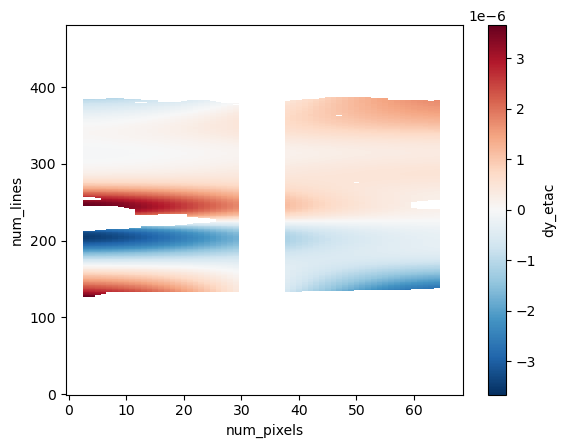

In [8]:
ds = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot',product, 'gaussian', f'pass{pass_}_{product}_{method}_{int(cutoff)}.nc'))
(ds.isel(cycle_number= 90)-ds.isel(cycle_number= 80)).dy_etac.plot()

In [7]:
os.path.join(zarr_dir, 'before_coloc','preprocessed_swot')

'/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot'

__________________
# 2km- Diff_only

In [7]:
product = 'swot2km'
method = 'diff_only'

if product == 'swot2km':
    dfs = browse_swot_2km().reset_index()
    
from cstes import zarr_dir
for pass_ in [3, 16] :
    df = dfs[dfs.pass_number==pass_]
    ds_swot = df.set_index('cycle_number').to_xarray()
    C = compute_filter_diff(ds_swot, filter_diff_method = method, filter_diff_kwargs={}, mean_sla=True).compute()
    C['pass_number'] = pass_
    C.to_netcdf(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, method, f'pass{pass_}_{product}_{method}.nc'))
        

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1236: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1257: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_0
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/

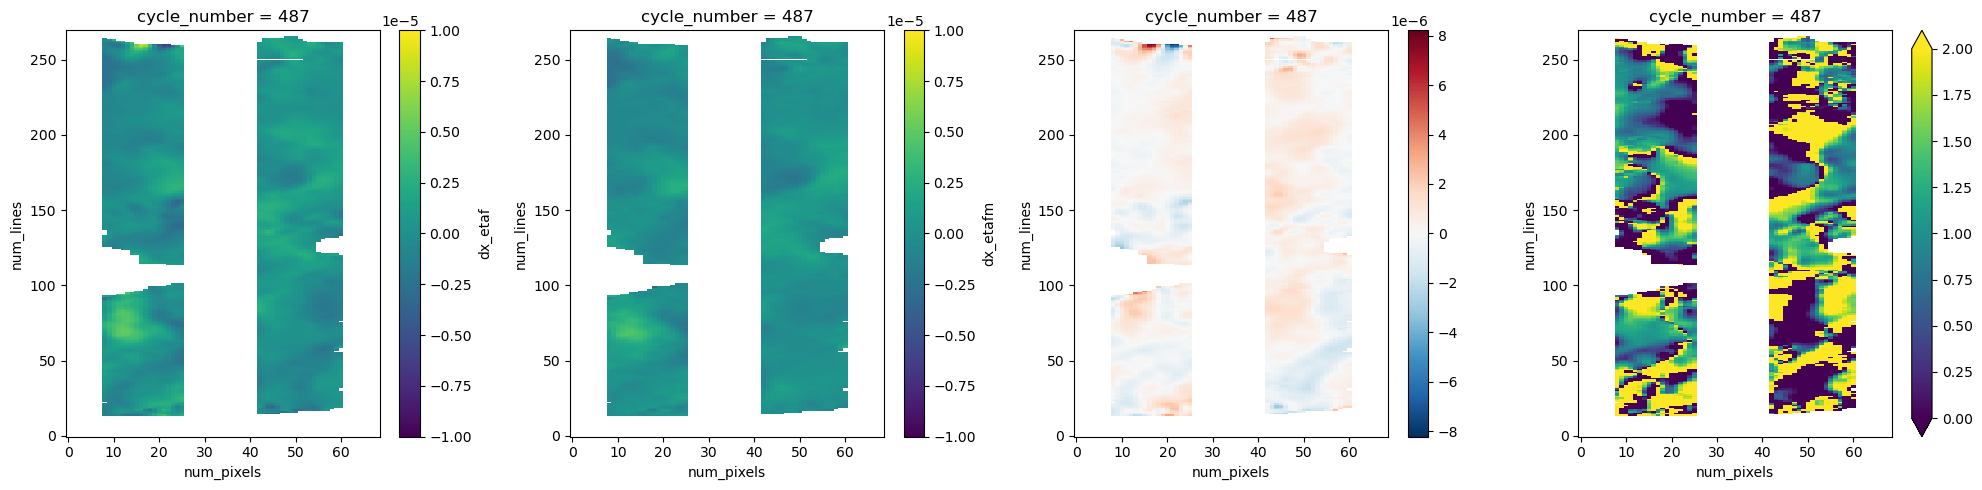

In [8]:
vmin, vmax = -1e-5, 1e-5
fig, axs = plt.subplots(1,4, figsize=(20, 5))
C.isel(cycle_number=10).dx_etaf.sel(num_lines = slice(120, 390)).plot(ax= axs[0], vmin=vmin, vmax=vmax, label = 'dx_etaf')
C.isel(cycle_number=10).dx_etafm.sel(num_lines = slice(120, 390)).plot(ax= axs[1], vmin=vmin, vmax=vmax, label = 'dx_etaf - mean sla')
(C.dx_etaf -C.dx_etafm).isel(cycle_number=10).sel(num_lines = slice(120, 390)).plot(ax= axs[2])
(C.dx_etaf /C.dx_etafm).isel(cycle_number=10).sel(num_lines = slice(120, 390)).plot(ax= axs[3], vmin=0, vmax=2)
fig.tight_layout()

__________________
# 2km- xarray diff

In [10]:
method = 'xarray_diff'
    
from cstes import zarr_dir
for pass_ in [3, 16] :
    df = dfs[dfs.pass_number==pass_]
    ds_swot = df.set_index('cycle_number').to_xarray()
    C = compute_filter_diff(ds_swot, filter_diff_method = method, filter_diff_kwargs={}, mean_sla=True).compute()
    C['pass_number'] = pass_
    C.to_netcdf(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, method, f'pass{pass_}_{product}_{method}.nc'))
        

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1236: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1257: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_0
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/

In [5]:
zarr_dir

'/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC'

_____________
# 2km-Fitting Kernel

In [11]:
method = 'fitting_kernel'

# Fitting kernel
from cstes import zarr_dir
for pass_ in [3, 16] :
    df = dfs[dfs.pass_number==pass_]
    ds_swot = df.set_index('cycle_number').to_xarray().chunk({'cycle_number':1}).persist()
    for npts in np.arange(5, 19, 2) :
        C = compute_filter_diff(ds_swot, filter_diff_method = method, filter_diff_kwargs={'npts':npts}, mean_sla=True).compute()
        C['pass_number'] = pass_
        C['npts'] = npts
        C.to_netcdf(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, method, f'pass{pass_}_{product}_{method}_{int(npts)}.nc'))

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1236: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1257: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_0
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/

___________
# Dataset containing other general variables (that will be only interpolated, not diff)

In [4]:
def preprocess(ds):
    ds = add_grid_metrics(ds)
    c = ds.cycle_number.mean().values
    ds = ds.assign_coords({"cycle_number": ("cycle_number", [c])})
    return ds[variables]

variables = ['ancillary_surface_classification_flag',
             'cross_track_distance',
             'distance_to_coast',
             'duacs_editing_flag',
             'duacs_phase_screen',
             'duacs_phase_screen_orbit',
             'duacs_phase_screen_static',
             'duacs_relative_vorticity',
             'duacs_speed_meridional',
             'duacs_speed_meridional_abs',
             'duacs_speed_zonal',
             'duacs_speed_zonal_abs',
             'duacs_strain',
             'duacs_xcal',
             'sig0_karin_2',
             'phi',
             'swh_model', 
             'ssh_karin_uncert',
             'cycle_number'
            ]
from cstes import version_swot
if version_swot=='2.0.1' :
    variables= variables + ['duacs_speed_zonal_unfiltered', 'duacs_speed_meridional_unfiltered']

In [16]:
dfs = browse_swot_2km().reset_index()


KeyboardInterrupt



In [ ]:
dfs

In [5]:
# Drifters
dsg = {}
product = 'swot2km'
# Alti general
if product == 'swot2km':
    dfs = browse_swot_2km().reset_index()
    df3 = dfs[dfs.pass_number==3]
    df16 = dfs[dfs.pass_number==16]
    dsg[3] = xr.open_mfdataset(df3.file.unique(), preprocess=preprocess, concat_dim='cycle_number', combine='nested')
    print(3)
    dsg[16] = xr.open_mfdataset(df16.file.unique(), preprocess=preprocess, concat_dim='cycle_number', combine='nested')
    print(16)
    
for pass_ in [3, 16]:
    ds = dsg[pass_]
    ds['pass_number'] = pass_
    ds.to_netcdf(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, 'general', f'pass{pass_}_{product}_general.nc'))


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: Runt

3


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: Runt

16


In [9]:
ds1 = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, 'general', f'pass{pass_}_{product}_general.nc'))

In [10]:
ds1

<xarray.Dataset> Size: 365MB
Dimensions:                                (cycle_number: 91, num_lines: 481,
                                            num_pixels: 69)
Coordinates:
    phi                                    (num_lines, num_pixels) float64 266kB ...
  * cycle_number                           (cycle_number) float64 728B 478.0 ...
    latitude                               (num_lines, num_pixels) float64 266kB ...
    latitude_nadir                         (cycle_number, num_lines) float64 350kB ...
    longitude                              (num_lines, num_pixels) float64 266kB ...
    longitude_nadir                        (cycle_number, num_lines) float64 350kB ...
    time                                   (cycle_number, num_lines) datetime64[ns] 350kB ...
    dx                                     (num_lines, num_pixels) float64 266kB ...
    dy                                     (num_lines, num_pixels) float64 266kB ...
Dimensions without coordinates: num_lines, num_pixels
Data variables: (12/18)
    ancillary_surface_classification_flag  (cycle_number, num_lines, num_pixels) float32 12MB ...
    cross_track_distance                   (cycle_number, num_lines, num_pixels) float32 12MB ...
    distance_to_coast                      (cycle_number, num_lines, num_pixels) float64 24MB ...
    duacs_editing_flag                     (cycle_number, num_lines, num_pixels) float32 12MB ...
    duacs_phase_screen                     (cycle_number, num_lines, num_pixels) float64 24MB ...
    duacs_phase_screen_orbit               (cycle_number, num_lines, num_pixels) float64 24MB ...
    ...                                     ...
    duacs_strain                           (cycle_number, num_lines, num_pixels) float64 24MB ...
    duacs_xcal                             (cycle_number, num_lines, num_pixels) float64 24MB ...
    sig0_karin_2                           (cycle_number, num_lines, num_pixels) float32 12MB ...
    swh_model                              (cycle_number, num_lines, num_pixels) float64 24MB ...
    ssh_karin_uncert                       (cycle_number, num_lines, num_pixels) float64 24MB ...
    pass_number                            int64 8B ...
Attributes:
    latc:     39.961324
    lonc:     4.3749
    phi:      76.80931729750104